# 🏦 Bank Loan & Credit Risk Analysis — Exploratory Data Analysis

## Project Overview

This project presents an Exploratory Data Analysis (EDA) of bank loan data to
understand borrower characteristics, loan patterns, credit profiles, and loan
outcomes.

The analysis focuses on important financial and customer-related variables
such as income, credit score, loan amount, interest rate, loan purpose,
employment experience, home ownership, and previous loan defaults.

The objective is to identify meaningful patterns and relationships within the
loan portfolio and generate data-driven insights that can support better
understanding of lending behavior and credit risk.

### Tools Used

- Python
- NumPy
- Pandas
- Matplotlib

### Analysis Approach

The project follows a structured EDA process:

**Data Understanding → Data Inspection → Data Cleaning → Data Processing →
Feature Engineering → Exploratory Analysis → Business Questions →
Business Insights → Recommendations → Conclusion**

## 💼 Business Problem

Financial institutions need to understand their borrowers and loan portfolios
to make informed lending decisions.

Loan applications contain information about customer income, credit history,
loan characteristics, and previous defaults. Analyzing this information can
help identify patterns in loan outcomes and understand which customer and loan
characteristics are associated with higher levels of credit risk.

This project analyzes historical loan application data to uncover these
patterns and translate them into meaningful business insights.

## 🎯 Project Objectives

The main objectives of this analysis are:

1. Understand the structure and characteristics of the loan dataset.
2. Identify and handle missing, duplicate, or inconsistent data.
3. Process variables into a suitable format for analysis.
4. Create useful features for deeper analysis.
5. Analyze loan outcomes across different customer and loan characteristics.
6. Identify patterns associated with credit risk and loan defaults.
7. Generate actionable business insights and recommendations.

## 📂 Dataset Overview

The dataset contains information about bank loan applicants and their loan
characteristics.

Key areas covered in the dataset include:

- Applicant demographics
- Income and employment information
- Home ownership
- Loan purpose
- Loan amount
- Interest rate
- Credit score
- Credit history
- Previous loan defaults
- Loan outcome

The dataset provides a useful foundation for analyzing borrower profiles and
understanding patterns within a bank's loan portfolio.

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [3]:
# Load the dataset

df = pd.read_csv("/kaggle/input/datasets/udaymalviya/bank-loan-data/loan_data.csv")

# Display the first five rows
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
# Check number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 45000
Number of Columns: 14


In [5]:
# Display column names

df.columns.tolist()

['person_age',
 'person_gender',
 'person_education',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'credit_score',
 'previous_loan_defaults_on_file',
 'loan_status']

In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [7]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [8]:
# Check missing values

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
person_age,0,0.0
person_gender,0,0.0
person_education,0,0.0
person_income,0,0.0
person_emp_exp,0,0.0
person_home_ownership,0,0.0
loan_amnt,0,0.0
loan_intent,0,0.0
loan_int_rate,0,0.0
loan_percent_income,0,0.0


In [9]:
# Check missing values

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
person_age,0,0.0
person_gender,0,0.0
person_education,0,0.0
person_income,0,0.0
person_emp_exp,0,0.0
person_home_ownership,0,0.0
loan_amnt,0,0.0
loan_intent,0,0.0
loan_int_rate,0,0.0
loan_percent_income,0,0.0


In [10]:
# Check duplicate rows

print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


## 🔍 Data Inspection

After loading the dataset, the next step is to inspect the individual
variables and identify potential data-quality issues.

This includes checking categorical values, numerical ranges, duplicate records,
and unusual observations before performing any data cleaning or feature
engineering.

In [11]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


person_gender:
['female' 'male']

person_education:
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

person_home_ownership:
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

loan_intent:
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

previous_loan_defaults_on_file:
['No' 'Yes']


In [12]:
# Summary of numerical variables

numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [13]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [14]:
# Check potentially invalid values

checks = {
    "Age <= 0": (df["person_age"] <= 0).sum(),
    "Income <= 0": (df["person_income"] <= 0).sum(),
    "Employment Experience < 0": (df["person_emp_exp"] < 0).sum(),
    "Loan Amount <= 0": (df["loan_amnt"] <= 0).sum(),
    "Interest Rate <= 0": (df["loan_int_rate"] <= 0).sum(),
    "Credit Score <= 0": (df["credit_score"] <= 0).sum(),
    "Loan Status outside 0/1": (~df["loan_status"].isin([0, 1])).sum()
}

pd.Series(checks)

Age <= 0                     0
Income <= 0                  0
Employment Experience < 0    0
Loan Amount <= 0             0
Interest Rate <= 0           0
Credit Score <= 0            0
Loan Status outside 0/1      0
dtype: int64

## 🧹 Data Cleaning

The dataset contains 45,000 records and 14 variables. Initial inspection shows
that there are no missing values.

The cleaning process focuses on:

- Checking and removing duplicate records if present
- Identifying invalid numerical values
- Verifying categorical values
- Confirming that the loan status variable contains valid binary values
- Ensuring numerical columns use appropriate data types

In [15]:
# Remove duplicate records

df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 45000


In [16]:
# Confirm missing values after cleaning

print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [17]:
# Confirm data types

df.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

## ⚙️ Data Processing

The dataset contains several categorical variables represented using text
values and a binary loan status variable represented by 0 and 1.

For easier interpretation during analysis, the loan status variable will be
converted into meaningful labels while retaining the original information.

In [18]:
# Create a descriptive loan status column

df["loan_status_label"] = df["loan_status"].map({
    0: "Default",
    1: "Approved"
})

df["loan_status_label"].value_counts()

loan_status_label
Default     35000
Approved    10000
Name: count, dtype: int64

In [19]:
# Frequency distribution of important categorical variables

for column in [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file",
    "loan_status_label"
]:
    print(f"\n{column}")
    print(df[column].value_counts())


person_gender
person_gender
male      24841
female    20159
Name: count, dtype: int64

person_education
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

person_home_ownership
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

previous_loan_defaults_on_file
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64

loan_status_label
loan_status_label
Default     35000
Approved    10000
Name: count, dtype: int64


## 🛠️ Feature Engineering

Feature engineering is used to create meaningful categories from numerical
variables.

These derived features make it easier to compare customer groups and identify
patterns in loan outcomes.

The following features will be created:

- Age Group
- Income Group
- Credit Score Group
- Loan Amount Group
- Interest Rate Group

In [20]:
# Create age groups

df["age_group"] = pd.cut(
    df["person_age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

df["age_group"].value_counts().sort_index()

age_group
18-25    20441
26-35    20073
36-45     3724
46-55      605
56+        150
Name: count, dtype: int64

In [21]:
# Create income groups

df["income_group"] = pd.cut(
    df["person_income"],
    bins=[0, 25000, 50000, 75000, 100000, np.inf],
    labels=["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"]
)

df["income_group"].value_counts().sort_index()

income_group
Low              1557
Lower-Middle    11490
Middle          13348
Upper-Middle     8581
High            10024
Name: count, dtype: int64

In [22]:
# Create credit score groups

df["credit_score_group"] = pd.cut(
    df["credit_score"],
    bins=[0, 579, 669, 739, 799, 850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

df["credit_score_group"].value_counts().sort_index()

credit_score_group
Poor          6901
Fair         26806
Good         11196
Very Good       94
Excellent        3
Name: count, dtype: int64

In [23]:
# Create loan amount groups

df["loan_amount_group"] = pd.cut(
    df["loan_amnt"],
    bins=[0, 5000, 10000, 20000, 30000, np.inf],
    labels=[
        "Up to 5K",
        "5K-10K",
        "10K-20K",
        "20K-30K",
        "30K+"
    ]
)

df["loan_amount_group"].value_counts().sort_index()

loan_amount_group
Up to 5K    13131
5K-10K      16610
10K-20K     12267
20K-30K      2703
30K+          289
Name: count, dtype: int64

In [24]:
# Create interest rate groups

df["interest_rate_group"] = pd.cut(
    df["loan_int_rate"],
    bins=[0, 8, 12, 16, 20, np.inf],
    labels=[
        "Below 8%",
        "8%-12%",
        "12%-16%",
        "16%-20%",
        "20%+"
    ]
)

df["interest_rate_group"].value_counts().sort_index()

interest_rate_group
Below 8%    10030
8%-12%      19648
12%-16%     13087
16%-20%      2235
20%+            0
Name: count, dtype: int64

In [25]:
# View the updated dataset

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_status_label,age_group,income_group,credit_score_group,loan_amount_group,interest_rate_group
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,Approved,18-25,Middle,Poor,30K+,16%-20%
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,Default,18-25,Low,Poor,Up to 5K,8%-12%
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,Approved,18-25,Low,Fair,5K-10K,12%-16%
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,Approved,18-25,Upper-Middle,Good,30K+,12%-16%
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,Approved,18-25,Middle,Fair,30K+,12%-16%


In [26]:
# Check final structure

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 45000
Columns: 20


## 📊 Exploratory Data Analysis

Exploratory Data Analysis is performed to understand patterns and relationships
within the loan portfolio.

The analysis focuses on borrower characteristics, loan characteristics, credit
profiles, and loan outcomes.

The following business questions will guide the analysis.

## Q1. What is the overall distribution of loan outcomes?

Understanding the distribution of loan outcomes provides an initial view of
the proportion of approved and defaulted loans in the dataset.

In [27]:
# Loan outcome distribution

loan_status_count = df["loan_status_label"].value_counts()

loan_status_count

loan_status_label
Default     35000
Approved    10000
Name: count, dtype: int64

In [28]:
# Calculate loan outcome percentages

loan_status_percentage = (
    df["loan_status_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_status_percentage

loan_status_label
Default     77.78
Approved    22.22
Name: proportion, dtype: float64

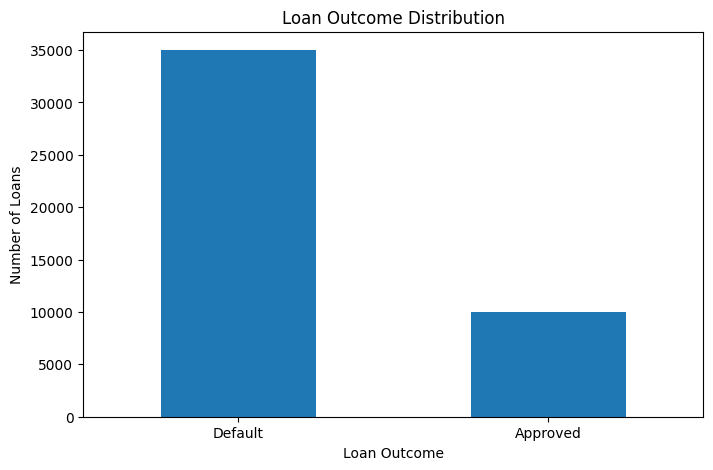

In [29]:
plt.figure(figsize=(8, 5))

loan_status_count.plot(kind="bar")

plt.title("Loan Outcome Distribution")
plt.xlabel("Loan Outcome")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)

plt.show()

### 💡 Business Insight

The dataset contains **45,000 loan applications**, of which **35,000 (77.78%)**
are classified as non-defaulted and **10,000 (22.22%)** are classified as
defaulted.

This indicates that the majority of applicants in the dataset did not
default, while approximately one-fifth of the applications resulted in
default.

The relatively large default group provides sufficient data to investigate
which borrower and loan characteristics are associated with higher default
risk.

## Q2. Which loan purposes are most common among applicants?

Understanding the purpose for which customers apply for loans helps identify
the major areas of demand within the bank's loan portfolio.

This analysis compares the number and proportion of applications across
different loan purposes.

In [30]:
# Loan applications by purpose

loan_purpose_count = df["loan_intent"].value_counts()

loan_purpose_count

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

In [31]:
# Percentage distribution of loan purposes

loan_purpose_percentage = (
    df["loan_intent"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_purpose_percentage

loan_intent
EDUCATION            20.34
MEDICAL              19.00
VENTURE              17.38
PERSONAL             16.78
DEBTCONSOLIDATION    15.88
HOMEIMPROVEMENT      10.63
Name: proportion, dtype: float64

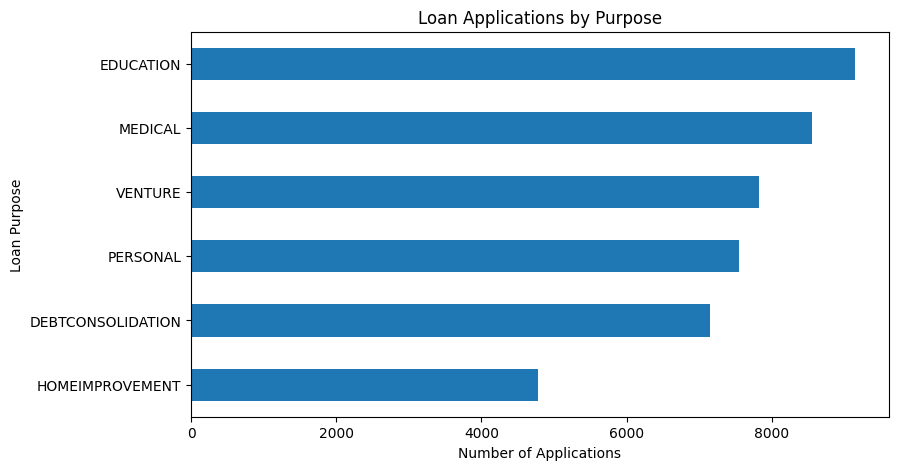

In [32]:
plt.figure(figsize=(9, 5))

loan_purpose_count.sort_values().plot(kind="barh")

plt.title("Loan Applications by Purpose")
plt.xlabel("Number of Applications")
plt.ylabel("Loan Purpose")

plt.show()

### 💡 Business Insight

**Education loans** represent the largest share of applications with **9,153
applications (20.34%)**, followed by **Medical loans** with **8,548 (19.00%)**.

**Venture loans** account for **7,819 applications (17.38%)**, while Personal
and Debt Consolidation loans represent **16.78%** and **15.88%** respectively.

**Home Improvement loans** have the lowest demand, with **4,783 applications
(10.63%)**.

Overall, Education and Medical loans together account for **39.34% of all loan
applications**, making them the two largest loan-purpose categories in the
dataset.

## Q3. How does applicant income vary across loan outcomes?

Applicant income is an important financial factor that can influence a
borrower's ability to manage loan repayments.

This analysis compares the income levels of applicants across default and
non-default loan outcomes to identify whether income is associated with
different loan outcomes.

In [33]:
df["loan_status_label"] = df["loan_status"].map({
    0: "Non-Default",
    1: "Default"
})

In [34]:
# Calculate average income by loan outcome

income_by_status = (
    df.groupby("loan_status_label")["person_income"]
    .mean()
    .round(2)
)

income_by_status

loan_status_label
Default        59886.10
Non-Default    86157.04
Name: person_income, dtype: float64

In [35]:
# Calculate median income by loan outcome

median_income_by_status = (
    df.groupby("loan_status_label")["person_income"]
    .median()
    .round(2)
)

median_income_by_status

loan_status_label
Default        50629.0
Non-Default    72928.0
Name: person_income, dtype: float64

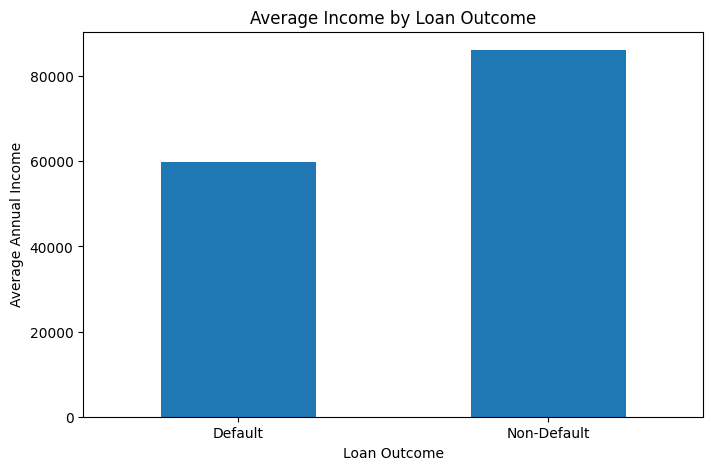

In [36]:
# Visualize average income by loan outcome

plt.figure(figsize=(8, 5))

income_by_status.plot(kind="bar")

plt.title("Average Income by Loan Outcome")
plt.xlabel("Loan Outcome")
plt.ylabel("Average Annual Income")
plt.xticks(rotation=0)

plt.show()

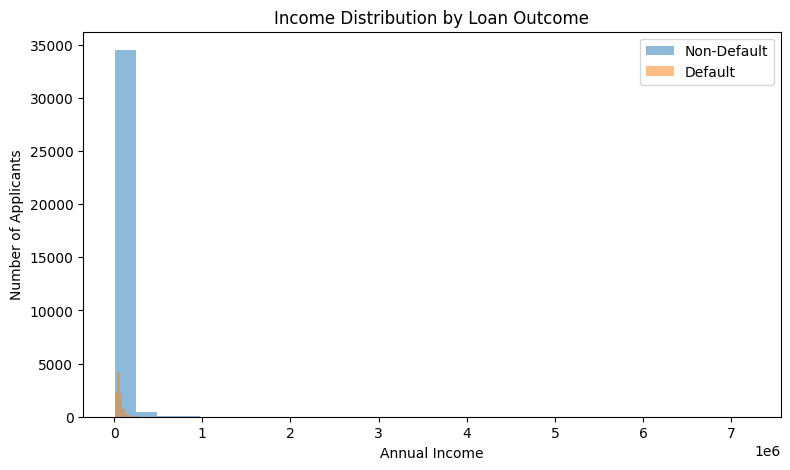

In [37]:
# Compare income distributions

plt.figure(figsize=(9, 5))

for status in ["Non-Default", "Default"]:
    df.loc[
        df["loan_status_label"] == status,
        "person_income"
    ].plot(
        kind="hist",
        bins=30,
        alpha=0.5,
        label=status
    )

plt.title("Income Distribution by Loan Outcome")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")
plt.legend()

plt.show()

### 💡 Business Insight

The analysis shows a clear difference in income levels between the two loan
outcome groups.

Applicants with **non-defaulted loans** have an average annual income of
**86,157.04**, compared with **59,886.10** for applicants with defaulted
loans.

The median income also follows the same pattern. Non-defaulted applicants have
a median income of **72,928**, while defaulted applicants have a median income
of **50,629**.

Overall, applicants with higher income levels appear to have lower default
levels in this dataset. This suggests that income may be an important factor
when assessing a borrower's ability to manage loan repayments.

## Q4. How does credit score relate to loan outcomes?

Credit score is an important indicator of a borrower's creditworthiness.

This analysis compares credit scores across default and non-default loan
outcomes to determine whether applicants with different credit profiles show
different loan outcomes.

In [38]:
# Calculate average credit score by loan outcome

credit_score_by_status = (
    df.groupby("loan_status_label")["credit_score"]
    .mean()
    .round(2)
)

credit_score_by_status

loan_status_label
Default        631.89
Non-Default    632.81
Name: credit_score, dtype: float64

In [39]:
# Calculate median credit score by loan outcome

median_credit_score_by_status = (
    df.groupby("loan_status_label")["credit_score"]
    .median()
    .round(2)
)

median_credit_score_by_status

loan_status_label
Default        639.0
Non-Default    640.0
Name: credit_score, dtype: float64

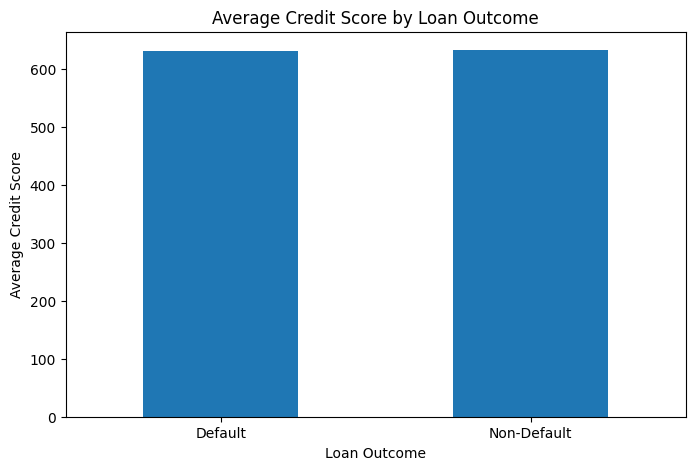

In [40]:
# Visualize average credit score by loan outcome

plt.figure(figsize=(8, 5))

credit_score_by_status.plot(kind="bar")

plt.title("Average Credit Score by Loan Outcome")
plt.xlabel("Loan Outcome")
plt.ylabel("Average Credit Score")
plt.xticks(rotation=0)

plt.show()

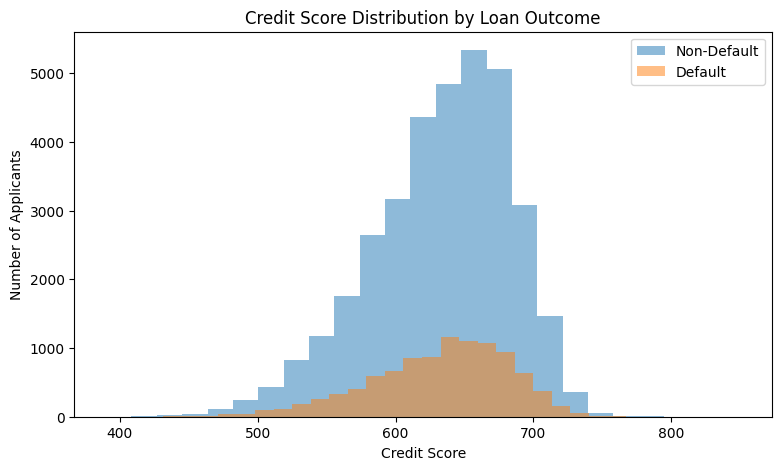

In [41]:
# Compare credit score distributions

plt.figure(figsize=(9, 5))

for status in ["Non-Default", "Default"]:
    df.loc[
        df["loan_status_label"] == status,
        "credit_score"
    ].plot(
        kind="hist",
        bins=25,
        alpha=0.5,
        label=status
    )

plt.title("Credit Score Distribution by Loan Outcome")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.legend()

plt.show()

In [42]:
# Loan outcome distribution across credit score groups

credit_group_status = pd.crosstab(
    df["credit_score_group"],
    df["loan_status_label"]
)

credit_group_status

loan_status_label,Default,Non-Default
credit_score_group,,
Poor,1539,5362
Fair,6027,20779
Good,2413,8783
Very Good,21,73
Excellent,0,3


In [43]:
# Calculate default rate by credit score group

default_rate_by_credit = (
    df.groupby("credit_score_group", observed=True)["loan_status"]
    .mean()
    .mul(100)
    .round(2)
)

default_rate_by_credit

credit_score_group
Poor         22.30
Fair         22.48
Good         21.55
Very Good    22.34
Excellent     0.00
Name: loan_status, dtype: float64

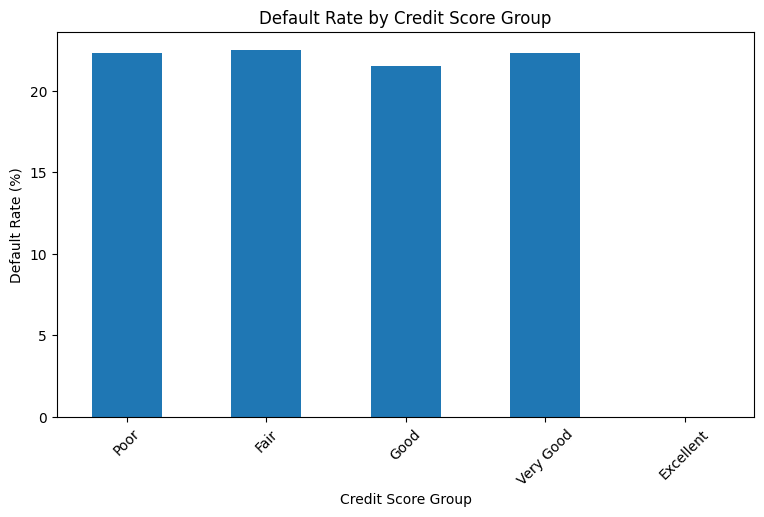

In [44]:
# Visualize default rate by credit score group

plt.figure(figsize=(9, 5))

default_rate_by_credit.plot(kind="bar")

plt.title("Default Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)

plt.show()

### 💡 Business Insight

The analysis shows that credit scores are very similar across default and
non-default applicants.

The average credit score is **631.89** for defaulted applicants compared with
**632.81** for non-defaulted applicants. Similarly, the median credit score is
**639** for defaulted applicants and **640** for non-defaulted applicants.

The default rate across the main credit score groups is also relatively
consistent, ranging from **21.55% to 22.48%**:

- **Poor:** 22.30%
- **Fair:** 22.48%
- **Good:** 21.55%
- **Very Good:** 22.34%

This indicates that **credit score alone does not appear to be a strong
differentiating factor between default and non-default outcomes in this
dataset**.

The Excellent credit score category has only **3 applicants**, so its 0%
default rate should not be considered representative.

Therefore, other factors such as income, previous loan defaults, loan amount,
interest rate, and loan purpose should also be examined to better understand
default risk.

## Q5. Which loan purposes have the highest default rates?

Different loan purposes may have different levels of financial risk.

This analysis compares the default rate across loan purposes to identify which
types of loans have relatively higher or lower default levels.

In [45]:
# Calculate default rate by loan purpose

default_rate_by_purpose = (
    df.groupby("loan_intent")["loan_status"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

default_rate_by_purpose

loan_intent
DEBTCONSOLIDATION    30.27
MEDICAL              27.82
HOMEIMPROVEMENT      26.30
PERSONAL             20.14
EDUCATION            16.96
VENTURE              14.43
Name: loan_status, dtype: float64

In [46]:
# Count defaulted loans by purpose

default_count_by_purpose = (
    df[df["loan_status"] == 1]["loan_intent"]
    .value_counts()
)

default_count_by_purpose

loan_intent
MEDICAL              2378
DEBTCONSOLIDATION    2163
EDUCATION            1552
PERSONAL             1521
HOMEIMPROVEMENT      1258
VENTURE              1128
Name: count, dtype: int64

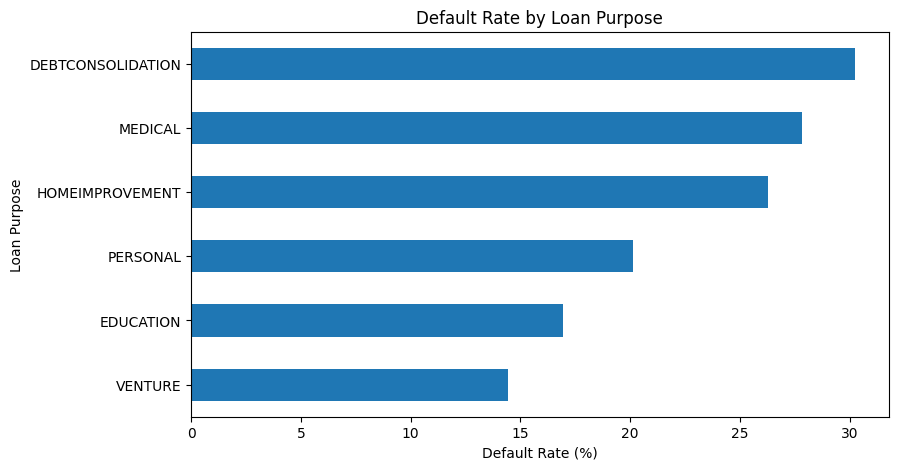

In [47]:
plt.figure(figsize=(9, 5))

default_rate_by_purpose.sort_values().plot(kind="barh")

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

plt.show()

In [48]:
# Create a summary table for loan purpose analysis

loan_purpose_summary = pd.DataFrame({
    "Applications": df["loan_intent"].value_counts(),
    "Defaults": default_count_by_purpose,
    "Default Rate (%)": default_rate_by_purpose
})

loan_purpose_summary = loan_purpose_summary.sort_values(
    by="Default Rate (%)",
    ascending=False
)

loan_purpose_summary

,Applications,Defaults,Default Rate (%)
loan_intent,,,
DEBTCONSOLIDATION,7145,2163,30.27
MEDICAL,8548,2378,27.82
HOMEIMPROVEMENT,4783,1258,26.30
PERSONAL,7552,1521,20.14
EDUCATION,9153,1552,16.96
VENTURE,7819,1128,14.43


### 💡 Business Insight

Default rates vary considerably across different loan purposes.

**Debt Consolidation** has the highest default rate at **30.27%**, followed by
**Medical loans at 27.82%** and **Home Improvement loans at 26.30%**.

Personal loans have a default rate of **20.14%**, while Education loans have a
lower default rate of **16.96%**.

**Venture loans have the lowest default rate at 14.43%**.

The difference between the highest default rate (Debt Consolidation: 30.27%)
and the lowest default rate (Venture: 14.43%) is **15.84 percentage points**.

This suggests that loan purpose may be more strongly associated with default
risk than credit score in this dataset. Financial institutions could therefore
consider loan purpose alongside other borrower characteristics when assessing
credit risk.

## Q6. How do loan amount and interest rate vary across loan outcomes?

Loan amount and interest rate are important characteristics of a loan and may
differ between borrowers with different loan outcomes.

This analysis compares the average loan amount and interest rate between
defaulted and non-defaulted applicants to identify potential differences in
loan characteristics.

In [49]:
# Average loan amount by loan outcome

loan_amount_by_status = (
    df.groupby("loan_status_label")["loan_amnt"]
    .mean()
    .round(2)
)

loan_amount_by_status

loan_status_label
Default        10855.69
Non-Default     9219.58
Name: loan_amnt, dtype: float64

In [50]:
# Average interest rate by loan outcome

interest_rate_by_status = (
    df.groupby("loan_status_label")["loan_int_rate"]
    .mean()
    .round(2)
)

interest_rate_by_status

loan_status_label
Default        12.86
Non-Default    10.48
Name: loan_int_rate, dtype: float64

In [51]:
# Median loan amount and interest rate

median_loan_amount = (
    df.groupby("loan_status_label")["loan_amnt"]
    .median()
    .round(2)
)

median_interest_rate = (
    df.groupby("loan_status_label")["loan_int_rate"]
    .median()
    .round(2)
)

print("Median Loan Amount:")
print(median_loan_amount)

print("\nMedian Interest Rate:")
print(median_interest_rate)

Median Loan Amount:
loan_status_label
Default        9750.0
Non-Default    8000.0
Name: loan_amnt, dtype: float64

Median Interest Rate:
loan_status_label
Default        12.98
Non-Default    10.85
Name: loan_int_rate, dtype: float64


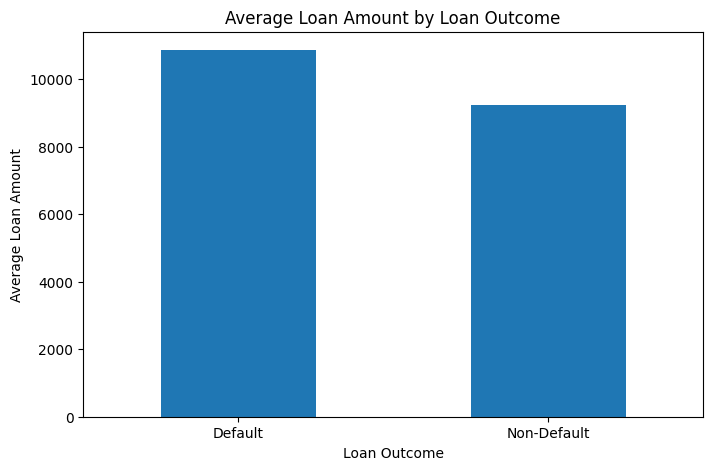

In [52]:
plt.figure(figsize=(8, 5))

loan_amount_by_status.plot(kind="bar")

plt.title("Average Loan Amount by Loan Outcome")
plt.xlabel("Loan Outcome")
plt.ylabel("Average Loan Amount")
plt.xticks(rotation=0)

plt.show()

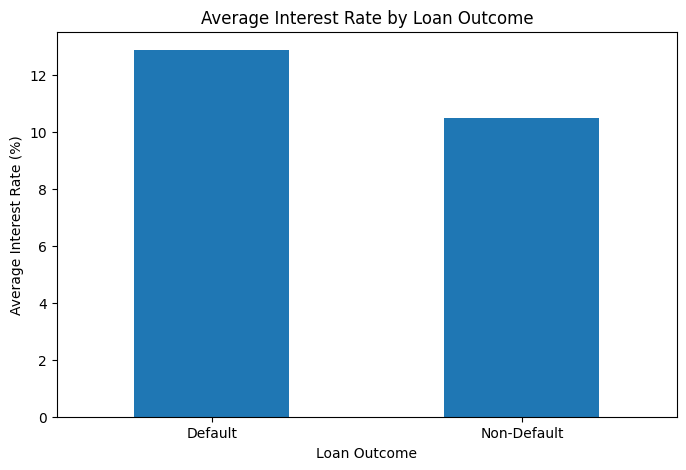

In [53]:
plt.figure(figsize=(8, 5))

interest_rate_by_status.plot(kind="bar")

plt.title("Average Interest Rate by Loan Outcome")
plt.xlabel("Loan Outcome")
plt.ylabel("Average Interest Rate (%)")
plt.xticks(rotation=0)

plt.show()

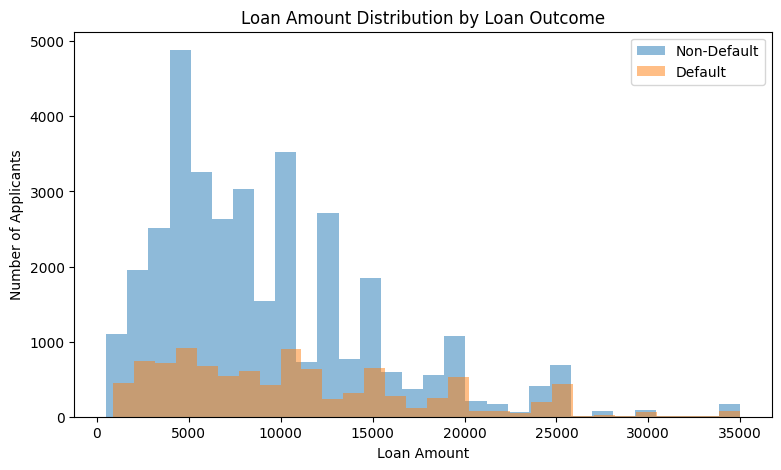

In [54]:
plt.figure(figsize=(9, 5))

for status in ["Non-Default", "Default"]:
    df.loc[
        df["loan_status_label"] == status,
        "loan_amnt"
    ].plot(
        kind="hist",
        bins=30,
        alpha=0.5,
        label=status
    )

plt.title("Loan Amount Distribution by Loan Outcome")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.legend()

plt.show()

### 💡 Business Insight

The analysis shows clear differences in loan characteristics between defaulted
and non-defaulted applicants.

Defaulted applicants have an average loan amount of **10,855.69**, compared
with **9,219.58** for non-defaulted applicants. The median loan amount also
follows the same pattern, at **9,750** for defaulted applicants compared with
**8,000** for non-defaulted applicants.

Interest rates show an even clearer difference. Defaulted applicants have an
average interest rate of **12.86%**, while non-defaulted applicants have an
average of **10.48%**. The median interest rate is **12.98%** for defaulted
applicants compared with **10.85%** for non-defaulted applicants.

Overall, defaulted applicants tend to have **larger loan amounts and higher
interest rates** than non-defaulted applicants. These loan characteristics
appear to be associated with higher default levels in this dataset.

## 💡 Key Business Insights

The analysis of 45,000 loan applications revealed several important patterns:

1. **Default Rate:**  
   **10,000 applicants (22.22%)** were classified as defaulted, while **35,000
   (77.78%)** were non-defaulted.

2. **Loan Demand:**  
   **Education loans** were the most common loan purpose, accounting for
   **9,153 applications (20.34%)**, followed by Medical loans at **19.00%**.

3. **Income and Default:**  
   Defaulted applicants had a lower average income of **59,886.10**, compared
   with **86,157.04** for non-defaulted applicants.

4. **Credit Score:**  
   Average credit scores were almost identical for defaulted (**631.89**) and
   non-defaulted (**632.81**) applicants. This suggests that credit score alone
   does not strongly differentiate loan outcomes in this dataset.

5. **Loan Purpose and Risk:**  
   **Debt Consolidation** had the highest default rate at **30.27%**, while
   **Venture loans** had the lowest at **14.43%**.

6. **Loan Amount:**  
   Defaulted applicants had a higher average loan amount (**10,855.69**) than
   non-defaulted applicants (**9,219.58**).

7. **Interest Rate:**  
   Defaulted applicants also had a higher average interest rate (**12.86%**)
   compared with non-defaulted applicants (**10.48%**).

## 🎯 Business Recommendations

Based on the findings from the analysis, the following recommendations can be
considered:

### 1. Strengthen Monitoring of High-Risk Loan Purposes

Debt Consolidation, Medical, and Home Improvement loans showed the highest
default rates. These categories could receive additional risk monitoring and
more detailed applicant assessment.

### 2. Consider Income During Credit Assessment

Defaulted applicants had considerably lower income levels than non-defaulted
applicants. Income should therefore remain an important factor when evaluating
a borrower's repayment capacity.

### 3. Review Higher Loan Amounts Carefully

Defaulted applicants had higher average and median loan amounts. Banks could
apply additional affordability checks when applicants request larger loans.

### 4. Evaluate Interest Rate and Repayment Capacity

Higher interest rates were observed among defaulted applicants. Lending
decisions should consider whether the proposed interest rate creates an
affordable repayment obligation for the borrower.

### 5. Do Not Rely on Credit Score Alone

Credit scores were very similar across default and non-default groups.
Therefore, credit score should be considered together with income, loan
purpose, loan amount, interest rate, and previous loan history.

### 6. Focus on Customer-Level Risk Assessment

A combination of borrower characteristics and loan characteristics can provide
a more complete view of credit risk than any single variable.

## 📝 Conclusion

This Exploratory Data Analysis examined **45,000 bank loan applications** to
understand borrower characteristics, loan patterns, and factors associated
with loan defaults.

The analysis found that defaulted applicants generally had **lower incomes,
larger loan amounts, and higher interest rates** compared with non-defaulted
applicants.

Loan purpose also showed a meaningful difference in default rates, with
**Debt Consolidation having the highest default rate at 30.27%**, while
**Venture loans had the lowest at 14.43%**.

In contrast, credit scores were very similar between defaulted and non-defaulted
applicants, indicating that credit score alone may not sufficiently explain
loan outcomes within this dataset.

Overall, the analysis demonstrates the importance of evaluating multiple
customer and loan characteristics together when understanding credit risk.
The findings can help financial institutions identify higher-risk segments,
improve monitoring, and support more informed lending decisions.

## ⚠️ Limitations

This analysis has several limitations:

- The analysis identifies relationships and patterns but does not establish
  direct cause-and-effect relationships.
- The dataset represents a specific set of loan applications and may not
  represent every banking customer or lending market.
- Some categories contain relatively few observations, such as the Excellent
  credit score group, making comparisons less reliable.
- The analysis focuses on the variables available in the dataset and does not
  include additional factors that may influence loan outcomes.
- No predictive machine learning model was developed, as the project focuses
  specifically on Exploratory Data Analysis.

## ⚠️ Limitations

This analysis has several limitations:

- The analysis identifies relationships and patterns but does not establish
  direct cause-and-effect relationships.
- The dataset represents a specific set of loan applications and may not
  represent every banking customer or lending market.
- Some categories contain relatively few observations, such as the Excellent
  credit score group, making comparisons less reliable.
- The analysis focuses on the variables available in the dataset and does not
  include additional factors that may influence loan outcomes.
- No predictive machine learning model was developed, as the project focuses
  specifically on Exploratory Data Analysis.

## 📚 References

1. Kaggle — Bank Loan Data  
   https://www.kaggle.com/datasets/udaymalviya/bank-loan-data

2. Pandas Documentation  
   https://pandas.pydata.org/docs/

3. NumPy Documentation  
   https://numpy.org/doc/

4. Matplotlib Documentation  
   https://matplotlib.org/stable/